In [1]:
from agents import Agent, Runner, function_tool

@function_tool
def get_weather(city:str):

    return "30 degrees"

agent = Agent(
    name = "Assistant Agent",
    instructions = " You are a helpful assistan. Use tools when needed to answer questions.",
    tools = [get_weather]
)
stream = Runner.run_streamed(agent, "Hello how are you? what is the weather in capital of Spain?")

async for event in stream.stream_events():
    if event.type == "raw_response_event":continue
    elif event.type == "agent_updated_stream_event":
        print("Agent updated to",event.new_agent.name)
    elif event.type == "run_item_stream_event":
        print("Run item",event.item)
        print("="*20)
    

Agent updated to Assistant Agent
Run item ToolCallItem(agent=Agent(name='Assistant Agent', handoff_description=None, tools=[FunctionTool(name='get_weather', description='', params_json_schema={'properties': {'city': {'title': 'City', 'type': 'string'}}, 'required': ['city'], 'title': 'get_weather_args', 'type': 'object', 'additionalProperties': False}, on_invoke_tool=<agents.tool._FailureHandlingFunctionToolInvoker object at 0x0000022F2E1EB750>, strict_json_schema=True, is_enabled=True, tool_input_guardrails=None, tool_output_guardrails=None, needs_approval=False, timeout_seconds=None, timeout_behavior='error_as_result', timeout_error_function=None, defer_loading=False)], mcp_servers=[], mcp_config={}, instructions=' You are a helpful assistan. Use tools when needed to answer questions.', prompt=None, handoffs=[], model=None, model_settings=ModelSettings(temperature=None, top_p=None, frequency_penalty=None, presence_penalty=None, tool_choice=None, parallel_tool_calls=None, truncation=N

In [6]:
from agents import Agent, Runner, function_tool, ItemHelpers

@function_tool
def get_weather(city:str):

    return "30 degrees"

agent = Agent(
    name = "Assistant Agent",
    instructions = " You are a helpful assistan. Use tools when needed to answer questions.",
    tools = [get_weather]
)
stream = Runner.run_streamed(agent, "Hello how are you? what is the weather in capital of Spain?")

async for event in stream.stream_events():
    if event.type == "raw_response_event":continue
    elif event.type == "agent_updated_stream_event":
        print("Agent updated to",event.new_agent.name)
    elif event.type == "run_item_stream_event":
        if event.item.type == "tool_call_item":
            print(event.item.raw_item.to_dict())
        elif event.item.type == "tool_call_output_item":
            print(event.item.output)
        elif event.item.type == "message_output_item":
            print(ItemHelpers.text_message_output(event.item))  # response에서 text 추출 
        print("="*20)

Agent updated to Assistant Agent
{'arguments': '{"city":"Madrid"}', 'call_id': 'call_f2Y5pcOXb3dyWQhumtW8uBmi', 'name': 'get_weather', 'type': 'function_call', 'id': 'fc_02e11d1147b21b3e006a309cdf0eec819b971d0bba56955ebc', 'status': 'completed'}
I’m doing well, thanks! The capital of Spain is Madrid. Let me check the weather there.
30 degrees
I’m doing well, thanks!

Weather in Madrid: 30 degrees.


In [16]:
from agents import Agent, Runner, function_tool, ItemHelpers

@function_tool
def get_weather(city:str):

    return "30 degrees"

agent = Agent(
    name = "Assistant Agent",
    instructions = " You are a helpful assistan. Use tools when needed to answer questions.",
    tools = [get_weather]
)
stream = Runner.run_streamed(agent, "Hello how are you? what is the weather in capital of Spain?")

message = ""
args = ""
async for event in stream.stream_events():
    if event.type == "raw_response_event":
        event_type = event.data.type
        if event_type == "response.output_text.delta":
            message += event.data.delta
            print(message)
        elif event_type == "response.function_call_arguments.delta":
            args += event.data.delta
            print(args)
        elif event_type == "response.completed":
            message = ""
            args = ""


{"
{"city
{"city":"
{"city":"Madrid
{"city":"Madrid"}
I
I’m
I’m good
I’m good,
I’m good, thanks
I’m good, thanks!
I’m good, thanks!  

I’m good, thanks!  
The
I’m good, thanks!  
The weather
I’m good, thanks!  
The weather in
I’m good, thanks!  
The weather in Madrid
I’m good, thanks!  
The weather in Madrid is
I’m good, thanks!  
The weather in Madrid is 
I’m good, thanks!  
The weather in Madrid is 30
I’m good, thanks!  
The weather in Madrid is 30 degrees
I’m good, thanks!  
The weather in Madrid is 30 degrees.


In [36]:
# a메모리 
from agents import Agent, Runner, function_tool, ItemHelpers, SQLiteSession

session = SQLiteSession("user_3","ai-memory.db")

@function_tool
def get_weather(city:str):

    return "30 degrees"

agent = Agent(
    name = "Assistant Agent",
    instructions = " You are a helpful assistan. Use tools when needed to answer questions.",
    tools = [get_weather]
)


In [39]:
result = await Runner.run(
    agent, 
    "what was my name again?",
    session=session)

print(result.final_output)

Sam.


In [ ]:
await session.clear_session() # 해당 유저 데이터 삭제 

In [38]:
# 데이터 추가 가능
await session.add_items([{"role":"user","content":"My name is sam"}])

In [29]:
await session.pop_item() # 최근 데이터 1개 삭제

{'role': 'user', 'content': 'My name is sam'}

In [41]:
## handoffs
# a메모리 
from agents import Agent, Runner, function_tool, ItemHelpers, SQLiteSession

session = SQLiteSession("user_3","ai-memory.db")


geography_agent = Agent(
    name = "Geo Expert Agent",
    instructions = " You are a expert in geography. you answer questions related to them.",
    handoff_description = "Use this to answer geography related questions."
)

economics_agent = Agent(
    name = "Economics Expert Agent",
    instructions = " You are a expert in economics. you answer questions related to them.",
    handoff_description = "Use this to answer economics related questions."
)

main_agent = Agent(
    name = "Main Agent",
    instructions = " You are a user facing agent. Transfer to the agent most capable of answering the user's question.",
    handoffs = [geography_agent, economics_agent]
)

In [44]:
result = await Runner.run(
    main_agent, 
    "Why do countries sell bonds?",
    session=session)

print(result.last_agent.name)
print(result.final_output)

Tool name 'transfer_to_Geo Expert Agent' contains invalid characters for function calling and has been transformed to 'transfer_to_geo_expert_agent'. Please use only letters, digits, and underscores to avoid potential naming conflicts.
Tool name 'transfer_to_Economics Expert Agent' contains invalid characters for function calling and has been transformed to 'transfer_to_economics_expert_agent'. Please use only letters, digits, and underscores to avoid potential naming conflicts.
Tool name 'transfer_to_Geo Expert Agent' contains invalid characters for function calling and has been transformed to 'transfer_to_geo_expert_agent'. Please use only letters, digits, and underscores to avoid potential naming conflicts.
Tool name 'transfer_to_Economics Expert Agent' contains invalid characters for function calling and has been transformed to 'transfer_to_economics_expert_agent'. Please use only letters, digits, and underscores to avoid potential naming conflicts.


Economics Expert Agent
Countries sell bonds to **borrow money**.

Main reasons:
- **Finance budget deficits**: cover spending when tax revenue isn’t enough.
- **Fund public projects**: roads, schools, infrastructure, defense.
- **Manage cash flow**: smooth government spending over time.
- **Refinance old debt**: pay off maturing bonds with new ones.

In short, bonds let governments raise large amounts of money now and repay it later with interest.


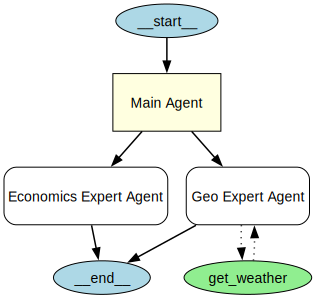

In [2]:
## 
from agents import Agent, Runner, SQLiteSession, function_tool
from agents.extensions.visualization import draw_graph
session = SQLiteSession("user_1","ai-memory.db")

@function_tool
def get_weather():
    return"30"

geography_agent = Agent(
    name = "Geo Expert Agent",
    instructions = " You are a expert in geography. you answer questions related to them.",
    handoff_description = "Use this to answer geography related questions.",
    tools = [get_weather]
)

economics_agent = Agent(
    name = "Economics Expert Agent",
    instructions = " You are a expert in economics. you answer questions related to them.",
    handoff_description = "Use this to answer economics related questions."
)

main_agent = Agent(
    name = "Main Agent",
    instructions = " You are a user facing agent. Transfer to the agent most capable of answering the user's question.",
    handoffs = [geography_agent, economics_agent]
)

draw_graph(main_agent)

In [5]:
## 
from agents import Agent, Runner, SQLiteSession, function_tool, trace
from agents.extensions.visualization import draw_graph
from pydantic import BaseModel
session = SQLiteSession("user_1111","ai-memory.db")

class Answer(BaseModel):
    answer:str
    background_explanation:str

@function_tool
def get_weather():
    return"30"

geography_agent = Agent(
    name = "Geo Expert Agent",
    instructions = " You are a expert in geography. you answer questions related to them.",
    handoff_description = "Use this to answer geography related questions.",
    tools = [get_weather],
    output_type = Answer
)

economics_agent = Agent(
    name = "Economics Expert Agent",
    instructions = " You are a expert in economics. you answer questions related to them.",
    handoff_description = "Use this to answer economics related questions."
)

main_agent = Agent(
    name = "Main Agent",
    instructions = " You are a user facing agent. Transfer to the agent most capable of answering the user's question.",
    handoffs = [geography_agent, economics_agent]
)


In [ ]:
with(trace("user_1111")):
    result = await Runner.run(
        main_agent, 
        "What is the capital of japan's northen province",
        session=session)
    
    result = await Runner.run(
        main_agent, 
        "What is the capital of korea's northen province",
        session=session)
    
    result = await Runner.run(
        main_agent, 
        "What is the capital of china's northen province",
        session=session)
        
 

Tool name 'transfer_to_Geo Expert Agent' contains invalid characters for function calling and has been transformed to 'transfer_to_geo_expert_agent'. Please use only letters, digits, and underscores to avoid potential naming conflicts.
Tool name 'transfer_to_Economics Expert Agent' contains invalid characters for function calling and has been transformed to 'transfer_to_economics_expert_agent'. Please use only letters, digits, and underscores to avoid potential naming conflicts.
Tool name 'transfer_to_Geo Expert Agent' contains invalid characters for function calling and has been transformed to 'transfer_to_geo_expert_agent'. Please use only letters, digits, and underscores to avoid potential naming conflicts.
Tool name 'transfer_to_Economics Expert Agent' contains invalid characters for function calling and has been transformed to 'transfer_to_economics_expert_agent'. Please use only letters, digits, and underscores to avoid potential naming conflicts.


Tool name 'transfer_to_Geo Expert Agent' contains invalid characters for function calling and has been transformed to 'transfer_to_geo_expert_agent'. Please use only letters, digits, and underscores to avoid potential naming conflicts.
Tool name 'transfer_to_Economics Expert Agent' contains invalid characters for function calling and has been transformed to 'transfer_to_economics_expert_agent'. Please use only letters, digits, and underscores to avoid potential naming conflicts.
Tool name 'transfer_to_Geo Expert Agent' contains invalid characters for function calling and has been transformed to 'transfer_to_geo_expert_agent'. Please use only letters, digits, and underscores to avoid potential naming conflicts.
Tool name 'transfer_to_Economics Expert Agent' contains invalid characters for function calling and has been transformed to 'transfer_to_economics_expert_agent'. Please use only letters, digits, and underscores to avoid potential naming conflicts.
Tool name 'transfer_to_Geo Exper

: 